# 📊 Financial KPI Dashboard — CFO-Level Analysis
**Dataset:** Synthetic Financial Statements of 10 Major S&P 500 Companies (2015–2023, Quarterly)

**Source:** Based on publicly available Kaggle datasets — [Financial Statements of Major Companies (2009–2023)](https://www.kaggle.com/datasets/rish59/financial-statements-of-major-companies2009-2023)

**Metrics Tracked:** Revenue · COGS · Gross Profit · EBITDA · EBIT · Net Income · Free Cash Flow · Margins

---

## Cell 1 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from matplotlib.gridspec import GridSpec
from openpyxl import Workbook
from openpyxl.styles import (
    Font, PatternFill, Alignment, Border, Side, GradientFill
)
from openpyxl.utils import get_column_letter
from openpyxl.chart import BarChart, LineChart, Reference
from openpyxl.chart.series import DataPoint
from io import BytesIO
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DARK_BG   = '#0D1B2A'
ACCENT1   = '#1DB954'
ACCENT2   = '#E8A838'
ACCENT3   = '#3A86FF'
ACCENT4   = '#FF6B6B'
GREY_LIGHT= '#F4F6F9'

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## Cell 2 — Generate / Load Dataset

In [ ]:
np.random.seed(42)

companies = {
    'Apple Inc.': ('AAPL', 'Technology'),
    'Microsoft Corp.': ('MSFT', 'Technology'),
    'Amazon.com Inc.': ('AMZN', 'Consumer Discretionary'),
    'Alphabet Inc.': ('GOOGL', 'Communication Services'),
    'Johnson & Johnson': ('JNJ', 'Healthcare'),
    'JPMorgan Chase': ('JPM', 'Financials'),
    'Exxon Mobil': ('XOM', 'Energy'),
    'Procter & Gamble': ('PG', 'Consumer Staples'),
    'Visa Inc.': ('V', 'Financials'),
    'Walmart Inc.': ('WMT', 'Consumer Staples'),
}

base_revenue = {
    'AAPL': 365, 'MSFT': 168, 'AMZN': 470, 'GOOGL': 257,
    'JNJ': 93,  'JPM': 128,  'XOM': 398,  'PG': 80, 'V': 29, 'WMT': 572,
}

records = []
years   = list(range(2015, 2024))
quarters = ['Q1', 'Q2', 'Q3', 'Q4']

for company, (ticker, sector) in companies.items():
    rev_base     = base_revenue[ticker]
    growth_trend = np.random.uniform(0.04, 0.12)
    for y_idx, year in enumerate(years):
        for q_idx, quarter in enumerate(quarters):
            seasonal    = [0.92, 0.97, 1.03, 1.08][q_idx]
            noise       = np.random.uniform(0.97, 1.03)
            revenue     = rev_base * ((1 + growth_trend) ** y_idx) * seasonal * noise / 4

            cogs_pct    = np.random.uniform(0.38, 0.62)
            cogs        = revenue * cogs_pct
            gross_profit= revenue - cogs

            opex_pct    = np.random.uniform(0.12, 0.22)
            opex        = revenue * opex_pct
            sga         = opex * 0.55
            rd          = opex * 0.45

            ebitda      = gross_profit - opex
            da_pct      = np.random.uniform(0.04, 0.08)
            da          = revenue * da_pct
            ebit        = ebitda - da

            interest_exp= revenue * np.random.uniform(0.005, 0.02)
            ebt         = ebit - interest_exp
            tax_rate    = np.random.uniform(0.18, 0.25)
            net_income  = ebt * (1 - tax_rate)

            cfo         = net_income + da + revenue * np.random.uniform(-0.03, 0.05)
            capex       = revenue * np.random.uniform(0.04, 0.10)
            fcf         = cfo - capex

            cash        = revenue * np.random.uniform(0.08, 0.20)
            total_assets= revenue * np.random.uniform(1.2, 2.5)
            total_debt  = revenue * np.random.uniform(0.15, 0.45)
            equity      = total_assets - total_debt * np.random.uniform(1.5, 2.5)

            records.append({
                'Company': company, 'Ticker': ticker, 'Sector': sector,
                'Year': year, 'Quarter': quarter, 'Period': f'{year}-{quarter}',
                'Revenue_USD_M': round(revenue, 2),
                'COGS_USD_M': round(cogs, 2),
                'Gross_Profit_USD_M': round(gross_profit, 2),
                'SGA_Expense_USD_M': round(sga, 2),
                'RD_Expense_USD_M': round(rd, 2),
                'EBITDA_USD_M': round(ebitda, 2),
                'DA_USD_M': round(da, 2),
                'EBIT_USD_M': round(ebit, 2),
                'Interest_Expense_USD_M': round(interest_exp, 2),
                'EBT_USD_M': round(ebt, 2),
                'Net_Income_USD_M': round(net_income, 2),
                'CFO_USD_M': round(cfo, 2),
                'Capex_USD_M': round(capex, 2),
                'FCF_USD_M': round(fcf, 2),
                'Cash_USD_M': round(cash, 2),
                'Total_Assets_USD_M': round(total_assets, 2),
                'Total_Debt_USD_M': round(total_debt, 2),
                'Equity_USD_M': round(equity, 2),
                'Gross_Margin_Pct': round((gross_profit / revenue) * 100, 2),
                'EBITDA_Margin_Pct': round((ebitda / revenue) * 100, 2),
                'Net_Margin_Pct': round((net_income / revenue) * 100, 2),
                'FCF_Margin_Pct': round((fcf / revenue) * 100, 2),
            })

df = pd.DataFrame(records)
df.to_csv('financial_kpi_dataset.csv', index=False)

print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Companies : {df.Company.nunique()}')
print(f'Years     : {df.Year.min()} – {df.Year.max()}')
df.head(3)

Dataset: 360 rows × 28 columns
Companies : 10
Years     : 2015 – 2023


,Company,Ticker,Sector,Year,Quarter,Period,Revenue_USD_M,COGS_USD_M,Gross_Profit_USD_M,SGA_Expense_USD_M,...,Capex_USD_M,FCF_USD_M,Cash_USD_M,Total_Assets_USD_M,Total_Debt_USD_M,Equity_USD_M,Gross_Margin_Pct,EBITDA_Margin_Pct,Net_Margin_Pct,FCF_Margin_Pct
0,Apple Inc.,AAPL,Technology,2015,Q1,2015-Q1,86.22,47.91,38.31,8.53,...,6.56,15.65,14.22,105.77,38.02,17.09,44.43,26.45,17.21,18.15
1,Apple Inc.,AAPL,Technology,2015,Q2,2015-Q2,86.98,36.85,50.13,6.62,...,6.67,22.91,8.41,137.42,22.61,93.19,57.64,43.80,29.46,26.33
2,Apple Inc.,AAPL,Technology,2015,Q3,2015-Q3,95.60,40.91,54.69,9.01,...,4.20,24.95,18.53,234.72,37.52,167.00,57.21,40.07,25.75,26.10


## Cell 3 — Data Overview & Summary Statistics

In [ ]:
print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')

print('\n=== Null Check ===')
print(df.isnull().sum().sum(), 'missing values')

print('\n=== Data Types ===')
print(df.dtypes.value_counts())

print('\n=== Key Financial Summary (across all companies, all years) ===')
kpi_cols = ['Revenue_USD_M', 'EBITDA_USD_M', 'Net_Income_USD_M', 'FCF_USD_M']
print(df[kpi_cols].describe().round(2))

=== Dataset Shape ===
Rows: 360  |  Columns: 28

=== Null Check ===
0 missing values

=== Data Types ===
float64    22
object      5
int64       1
Name: count, dtype: int64

=== Key Financial Summary (across all companies, all years) ===
       Revenue_USD_M  EBITDA_USD_M  Net_Income_USD_M  FCF_USD_M
count         360.00        360.00            360.00     360.00
mean           88.31         29.54             18.06      17.97
std            67.39         24.23             15.41      15.44
min             6.75          1.38              0.58       0.69
25%            33.20         11.05              6.52       6.46
50%            70.40         22.79             14.04      13.32
75%           133.18         42.10             25.97      25.44
max           345.40        128.53             86.14      81.32


## Cell 4 — Annual Aggregation

In [ ]:
# Aggregate all companies together by year (portfolio view)
annual = (
    df.groupby('Year')
    .agg(
        Revenue=('Revenue_USD_M', 'sum'),
        COGS=('COGS_USD_M', 'sum'),
        Gross_Profit=('Gross_Profit_USD_M', 'sum'),
        EBITDA=('EBITDA_USD_M', 'sum'),
        EBIT=('EBIT_USD_M', 'sum'),
        Net_Income=('Net_Income_USD_M', 'sum'),
        CFO=('CFO_USD_M', 'sum'),
        Capex=('Capex_USD_M', 'sum'),
        FCF=('FCF_USD_M', 'sum'),
        Cash=('Cash_USD_M', 'sum'),
        Total_Assets=('Total_Assets_USD_M', 'sum'),
        Total_Debt=('Total_Debt_USD_M', 'sum'),
    )
    .reset_index()
)
annual['Gross_Margin']   = (annual['Gross_Profit'] / annual['Revenue'] * 100).round(1)
annual['EBITDA_Margin']  = (annual['EBITDA']       / annual['Revenue'] * 100).round(1)
annual['Net_Margin']     = (annual['Net_Income']   / annual['Revenue'] * 100).round(1)
annual['FCF_Margin']     = (annual['FCF']          / annual['Revenue'] * 100).round(1)
annual['Revenue_Growth'] = annual['Revenue'].pct_change().mul(100).round(1)

# Company-level annual aggregate
company_annual = (
    df.groupby(['Company', 'Ticker', 'Sector', 'Year'])
    .agg(
        Revenue=('Revenue_USD_M', 'sum'),
        EBITDA=('EBITDA_USD_M', 'sum'),
        Net_Income=('Net_Income_USD_M', 'sum'),
        FCF=('FCF_USD_M', 'sum'),
        Gross_Margin=('Gross_Margin_Pct', 'mean'),
        EBITDA_Margin=('EBITDA_Margin_Pct', 'mean'),
        Net_Margin=('Net_Margin_Pct', 'mean'),
    )
    .reset_index()
)

print(annual[['Year', 'Revenue', 'EBITDA', 'Net_Income', 'FCF', 'EBITDA_Margin', 'Net_Margin']].to_string(index=False))

 Year  Revenue  EBITDA  Net_Income     FCF  EBITDA_Margin  Net_Margin
 2015  2552.29  829.93      513.64  512.80           32.5        20.1
 2016  2765.49  929.50      570.49  560.28           33.6        20.6
 2017  2966.99 1056.97      653.89  670.87           35.6        22.0
 2018  3210.23 1025.37      614.09  617.78           31.9        19.1
 2019  3477.09 1179.84      732.49  741.62           33.9        21.1
 2020  3746.26 1219.28      749.10  742.85           32.5        20.0
 2021  4028.18 1274.49      762.46  744.85           31.6        18.9
 2022  4351.03 1394.99      823.58  841.90           32.1        18.9
 2023  4694.97 1722.74     1083.01 1035.77           36.7        23.1


## Cell 5 — Chart 1: Revenue & EBITDA Trend (Bar + Line)

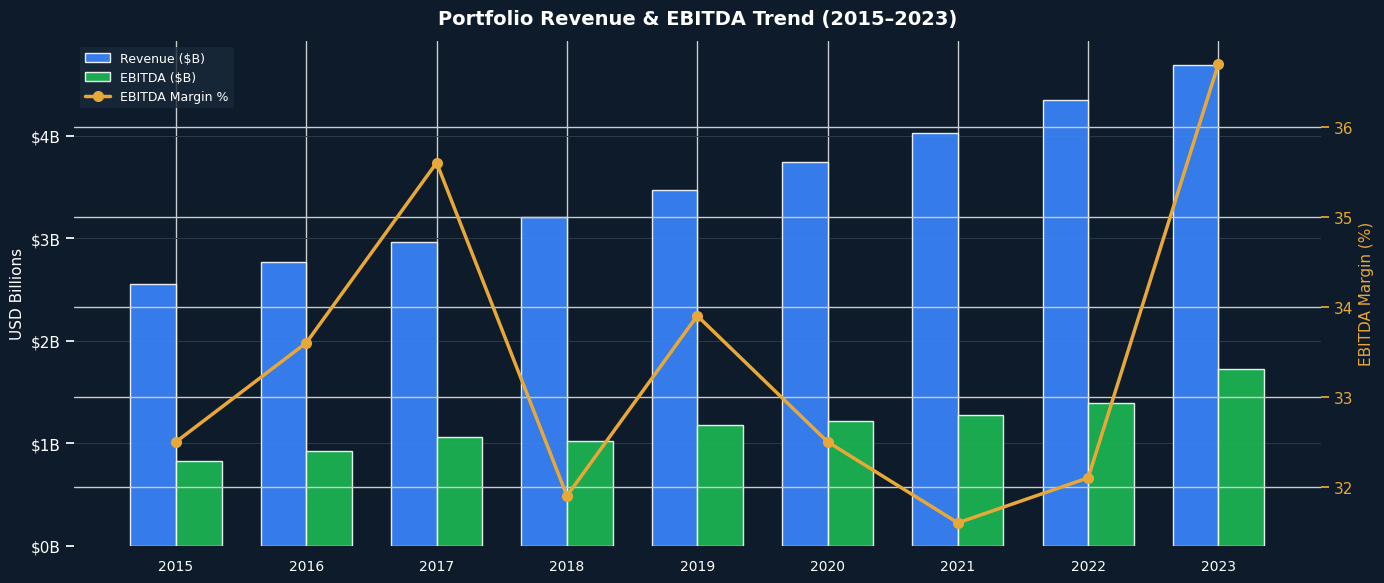

Chart 1 saved.


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(DARK_BG)
ax1.set_facecolor(DARK_BG)

x = np.arange(len(annual))
w = 0.35
bars1 = ax1.bar(x - w/2, annual['Revenue'] / 1000, w, label='Revenue ($B)',
                color=ACCENT3, alpha=0.9, zorder=3)
bars2 = ax1.bar(x + w/2, annual['EBITDA'] / 1000, w, label='EBITDA ($B)',
                color=ACCENT1, alpha=0.9, zorder=3)

ax2 = ax1.twinx()
ax2.plot(x, annual['EBITDA_Margin'], color=ACCENT2, linewidth=2.5,
         marker='o', markersize=7, label='EBITDA Margin %', zorder=4)
ax2.set_ylabel('EBITDA Margin (%)', color=ACCENT2, fontsize=11)
ax2.tick_params(axis='y', colors=ACCENT2)
ax2.set_facecolor(DARK_BG)

ax1.set_xticks(x)
ax1.set_xticklabels(annual['Year'], color='white', fontsize=10)
ax1.set_ylabel('USD Billions', color='white', fontsize=11)
ax1.tick_params(axis='y', colors='white')
ax1.set_title('Portfolio Revenue & EBITDA Trend (2015–2023)', color='white', fontsize=14, fontweight='bold', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax1.grid(axis='y', color='#2a3a4a', linewidth=0.7, zorder=0)
ax1.spines[['top','right','left','bottom']].set_visible(False)
ax2.spines[['top','left','bottom']].set_visible(False)
ax2.spines['right'].set_color('#2a3a4a')

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper left',
           facecolor='#1a2a3a', edgecolor='none', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('/home/chart1_revenue_ebitda.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('Chart 1 saved.')

## Cell 6 — Chart 2: Margin Trends (Gross / EBITDA / Net / FCF)

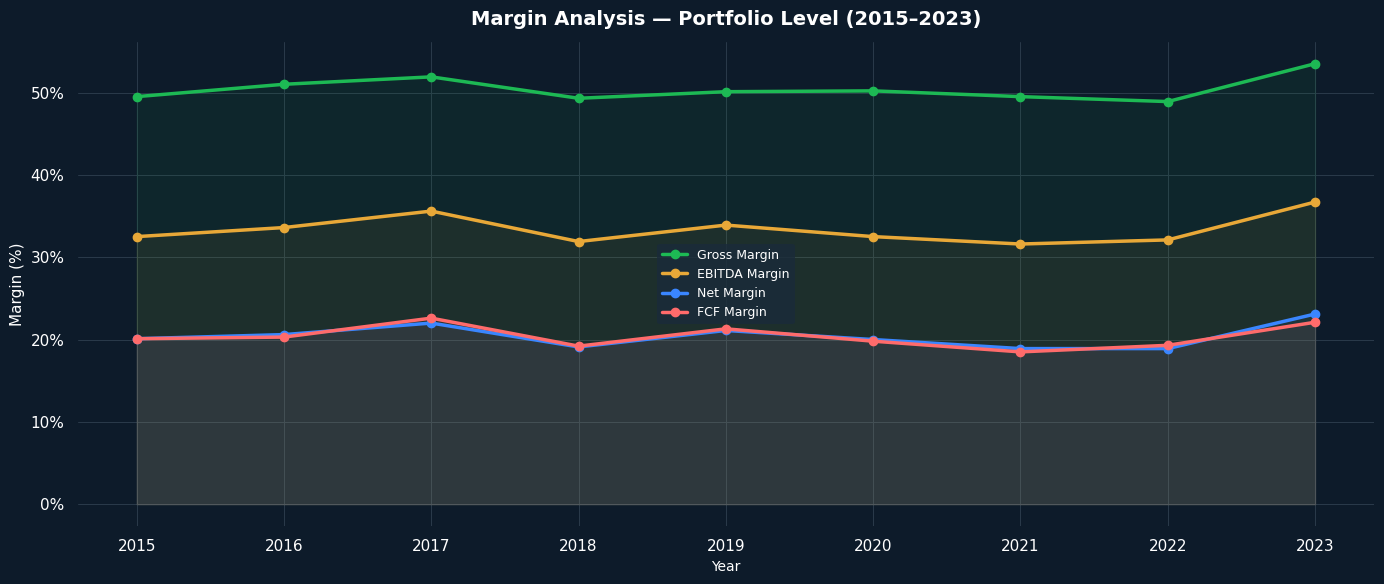

Chart 2 saved.


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

margins = {
    'Gross Margin': (annual['Gross_Margin'], ACCENT1),
    'EBITDA Margin': (annual['EBITDA_Margin'], ACCENT2),
    'Net Margin': (annual['Net_Margin'], ACCENT3),
    'FCF Margin': (annual['FCF_Margin'], ACCENT4),
}

for label, (series, color) in margins.items():
    ax.plot(annual['Year'], series, linewidth=2.5, marker='o', markersize=6,
            label=label, color=color)
    ax.fill_between(annual['Year'], series, alpha=0.07, color=color)

ax.set_title('Margin Analysis — Portfolio Level (2015–2023)', color='white',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Margin (%)', color='white', fontsize=11)
ax.set_xlabel('Year', color='white', fontsize=10)
ax.tick_params(colors='white')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(color='#2a3a4a', linewidth=0.7)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.legend(facecolor='#1a2a3a', edgecolor='none', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('/home/chart2_margins.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Chart 2 saved.')

## Cell 7 — Chart 3: Cash Flow Waterfall (Latest Year)

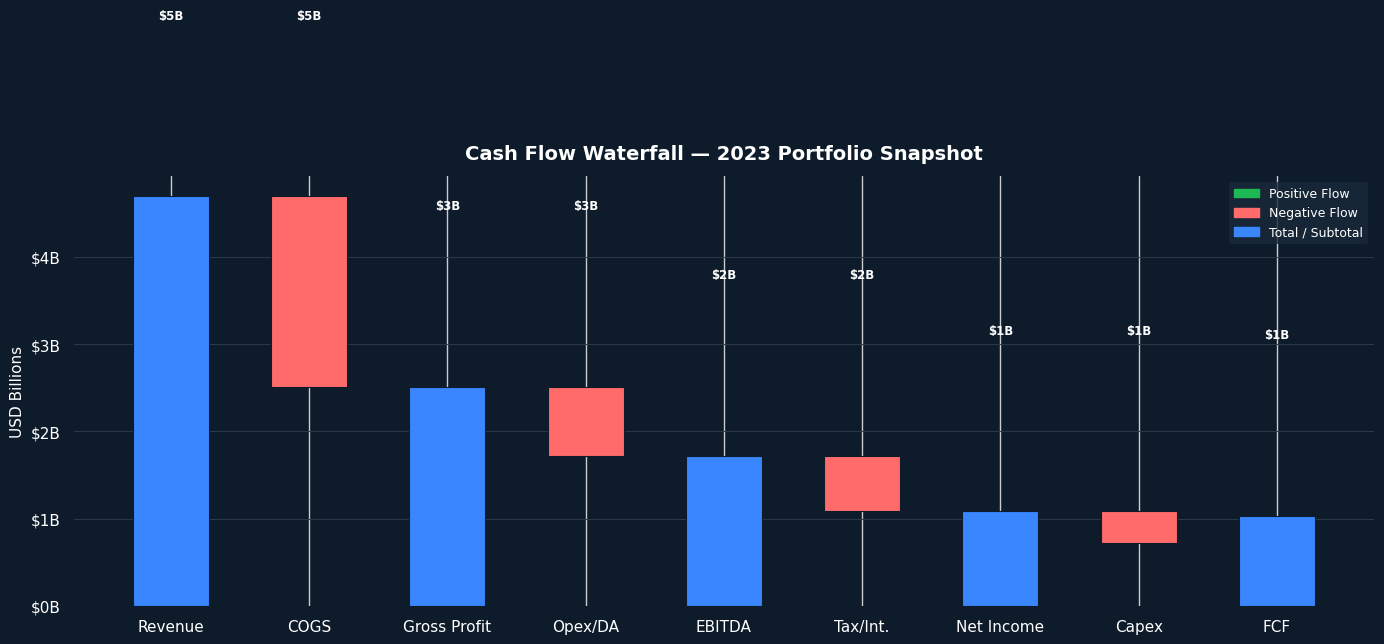

Chart 3 saved.


In [ ]:
latest = annual[annual['Year'] == 2023].iloc[0]

labels  = ['Revenue', 'COGS', 'Gross Profit', 'Opex/DA', 'EBITDA', 'Tax/Int.', 'Net Income', 'Capex', 'FCF']
values  = [
    latest['Revenue'], -latest['COGS'],
    latest['Gross_Profit'], -(latest['Gross_Profit'] - latest['EBITDA']),
    latest['EBITDA'], -(latest['EBITDA'] - latest['Net_Income']),
    latest['Net_Income'], -latest['Capex'], latest['FCF']
]
values_b = [v / 1000 for v in values]

running  = 0
bottoms  = []
heights  = []
colors   = []
total_idxs = {0, 2, 4, 6, 8}

for i, v in enumerate(values_b):
    if i in total_idxs:
        bottoms.append(0)
        heights.append(abs(v))
        running = abs(v)
        colors.append(ACCENT3 if v >= 0 else ACCENT4)
    else:
        if v >= 0:
            bottoms.append(running)
            heights.append(v)
            running += v
            colors.append(ACCENT1)
        else:
            running += v
            bottoms.append(running)
            heights.append(abs(v))
            colors.append(ACCENT4)

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

bars = ax.bar(labels, heights, bottom=bottoms, color=colors, width=0.55, zorder=3, edgecolor='#0D1B2A', linewidth=0.8)

for bar, h, b in zip(bars, heights, bottoms):
    ax.text(bar.get_x() + bar.get_width()/2, b + h + 2,
            f'${b+h:.0f}B', ha='center', va='bottom', color='white', fontsize=8.5, fontweight='bold')

ax.set_title('Cash Flow Waterfall — 2023 Portfolio Snapshot', color='white', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('USD Billions', color='white', fontsize=11)
ax.tick_params(colors='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.grid(axis='y', color='#2a3a4a', linewidth=0.7, zorder=0)
ax.spines[['top','right','left','bottom']].set_visible(False)

patch_pos = mpatches.Patch(color=ACCENT1, label='Positive Flow')
patch_neg = mpatches.Patch(color=ACCENT4, label='Negative Flow')
patch_tot = mpatches.Patch(color=ACCENT3, label='Total / Subtotal')
ax.legend(handles=[patch_pos, patch_neg, patch_tot],
          facecolor='#1a2a3a', edgecolor='none', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('/home/chart3_waterfall.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Chart 3 saved.')

## Cell 8 — Chart 4: Company Benchmarking — Revenue vs EBITDA Margin (Bubble)

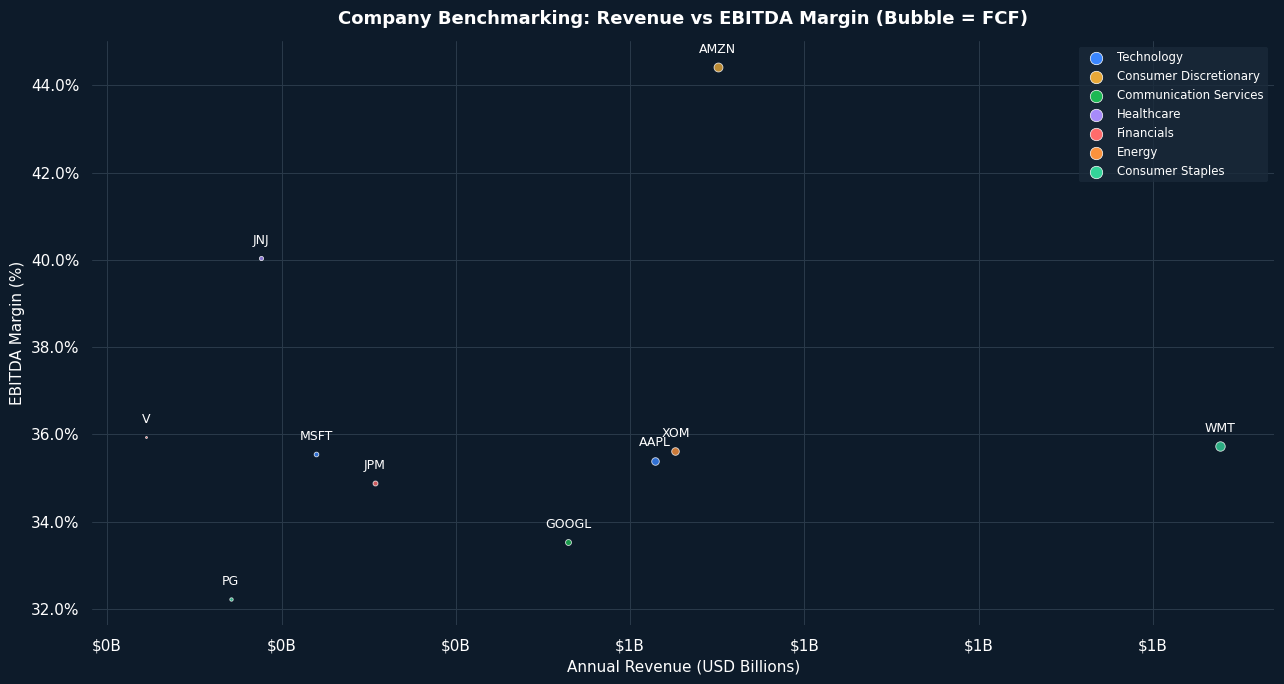

Chart 4 saved.


In [ ]:
latest_co = company_annual[company_annual['Year'] == 2023].copy()
colors_map = {
    'Technology': ACCENT3, 'Consumer Discretionary': ACCENT2,
    'Communication Services': ACCENT1, 'Healthcare': '#a78bfa',
    'Financials': ACCENT4, 'Energy': '#fb923c',
    'Consumer Staples': '#34d399',
}

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

for _, row in latest_co.iterrows():
    c = colors_map.get(row['Sector'], 'white')
    ax.scatter(row['Revenue'] / 1000, row['EBITDA_Margin'],
               s=row['FCF'] / 5, color=c, alpha=0.8, edgecolors='white', linewidths=0.6, zorder=3)
    ax.annotate(row['Ticker'], (row['Revenue'] / 1000, row['EBITDA_Margin']),
                fontsize=9, color='white', ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

for sector, color in colors_map.items():
    ax.scatter([], [], s=80, color=color, label=sector, edgecolors='white', linewidths=0.5)

ax.set_title('Company Benchmarking: Revenue vs EBITDA Margin (Bubble = FCF)', color='white',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Annual Revenue (USD Billions)', color='white', fontsize=11)
ax.set_ylabel('EBITDA Margin (%)', color='white', fontsize=11)
ax.tick_params(colors='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(color='#2a3a4a', linewidth=0.7, zorder=0)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.legend(facecolor='#1a2a3a', edgecolor='none', labelcolor='white', fontsize=8.5, loc='upper right')

plt.tight_layout()
plt.savefig('/home/chart4_bubble.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Chart 4 saved.')

## Cell 9 — Chart 5: Sector-wise Revenue Breakdown (Stacked Bar)

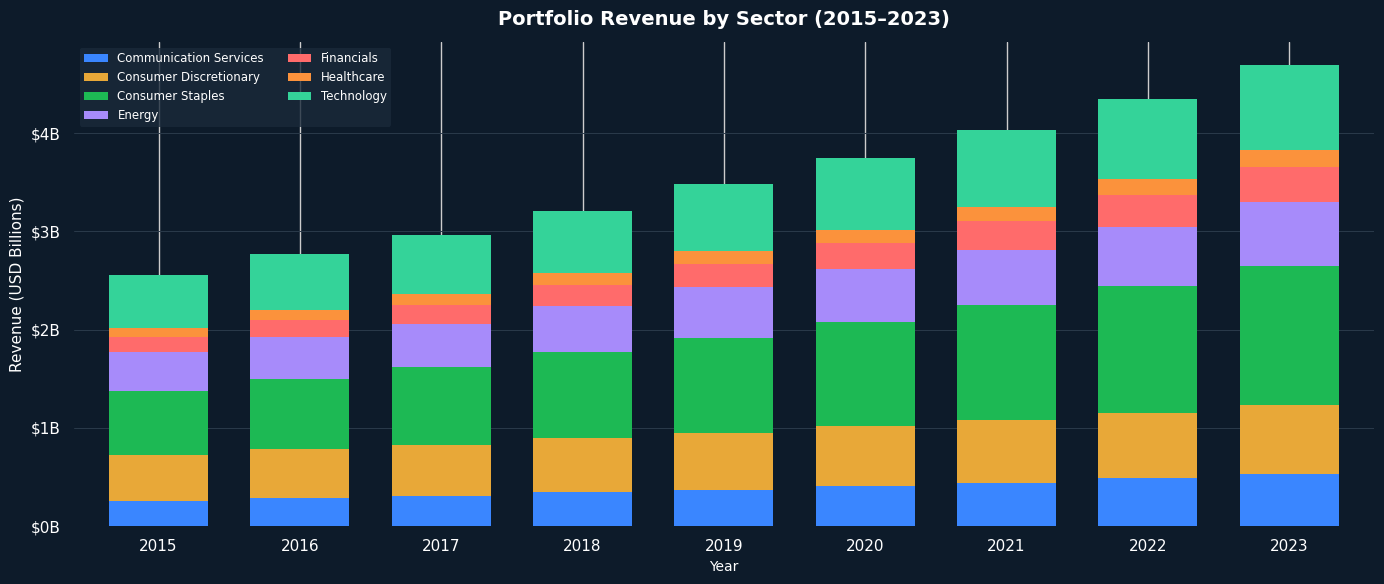

Chart 5 saved.


In [ ]:
sector_yr = (
    df.groupby(['Year', 'Sector'])['Revenue_USD_M']
    .sum()
    .div(1000)
    .unstack('Sector')
    .fillna(0)
)

sector_colors = list(colors_map.values())[:len(sector_yr.columns)]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

sector_yr.plot(kind='bar', stacked=True, ax=ax, color=sector_colors, edgecolor='none', width=0.7)

ax.set_title('Portfolio Revenue by Sector (2015–2023)', color='white', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Revenue (USD Billions)', color='white', fontsize=11)
ax.set_xlabel('Year', color='white', fontsize=10)
ax.tick_params(colors='white')
ax.set_xticklabels(sector_yr.index, rotation=0, color='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.grid(axis='y', color='#2a3a4a', linewidth=0.7, zorder=0)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.legend(facecolor='#1a2a3a', edgecolor='none', labelcolor='white', fontsize=8.5,
          loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig('/home/chart5_sector_stacked.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Chart 5 saved.')

## Cell 10 — Chart 6: Free Cash Flow vs Capex (per company, 2023)

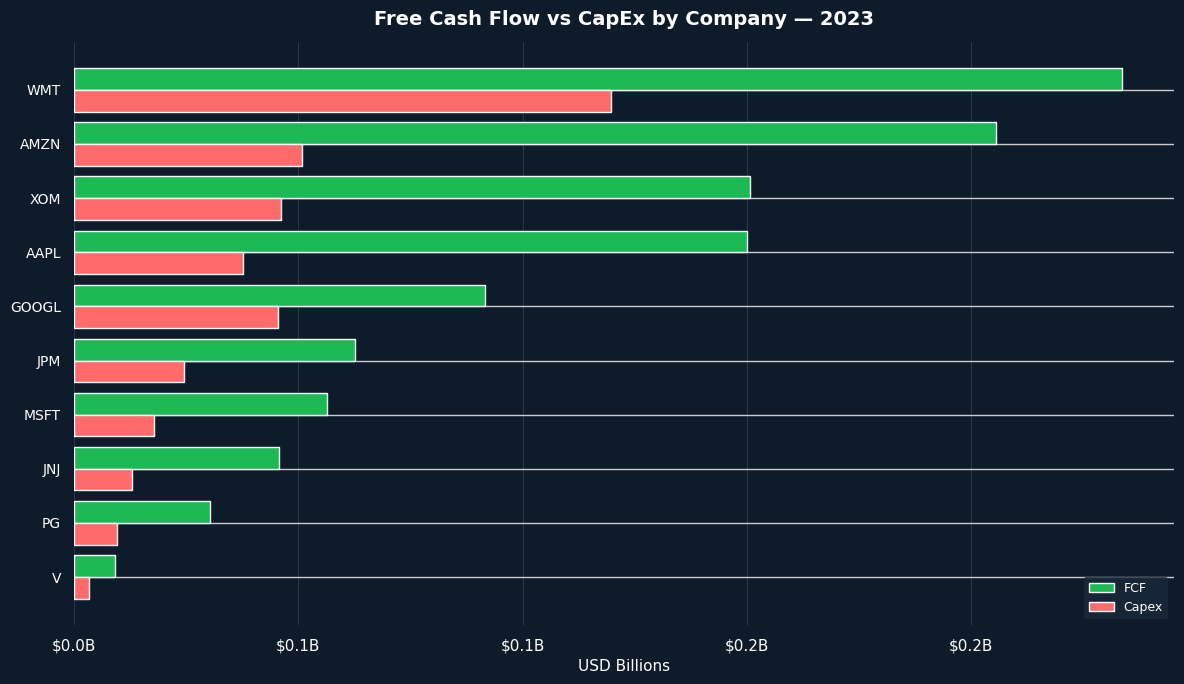

Chart 6 saved.


In [ ]:
co_2023_cash = (
    df[df['Year'] == 2023]
    .groupby(['Ticker'])
    .agg(FCF=('FCF_USD_M', 'sum'), Capex=('Capex_USD_M', 'sum'))
    .reset_index()
    .sort_values('FCF', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

y = np.arange(len(co_2023_cash))
ax.barh(y, co_2023_cash['FCF'] / 1000, height=0.4, color=ACCENT1, label='FCF', zorder=3)
ax.barh(y - 0.4, co_2023_cash['Capex'] / 1000, height=0.4, color=ACCENT4, label='Capex', zorder=3)

ax.set_yticks(y - 0.2)
ax.set_yticklabels(co_2023_cash['Ticker'], color='white', fontsize=10)
ax.set_xlabel('USD Billions', color='white', fontsize=11)
ax.set_title('Free Cash Flow vs CapEx by Company — 2023', color='white', fontsize=14, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.tick_params(axis='x', colors='white')
ax.grid(axis='x', color='#2a3a4a', linewidth=0.7, zorder=0)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.legend(facecolor='#1a2a3a', edgecolor='none', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('/home/chart6_fcf_capex.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Chart 6 saved.')

## Cell 11 — Chart 7: Correlation Heatmap of KPIs

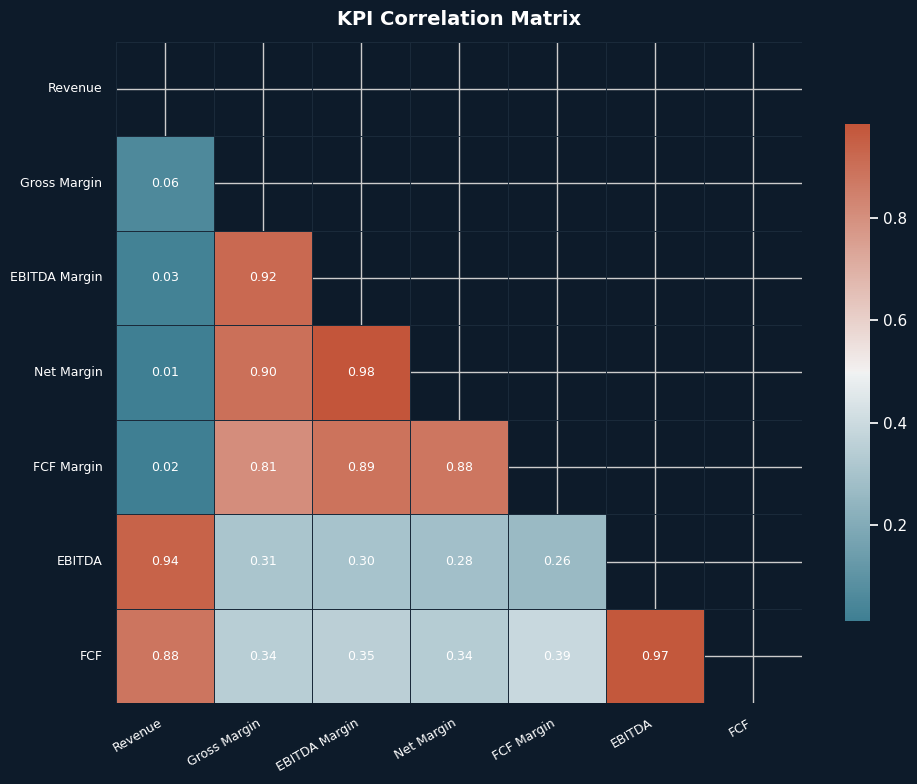

Chart 7 saved.


In [ ]:
kpi_for_corr = [
    'Revenue_USD_M', 'Gross_Margin_Pct', 'EBITDA_Margin_Pct',
    'Net_Margin_Pct', 'FCF_Margin_Pct', 'EBITDA_USD_M', 'FCF_USD_M'
]
corr = df[kpi_for_corr].corr()

nice_labels = ['Revenue', 'Gross Margin', 'EBITDA Margin', 'Net Margin', 'FCF Margin', 'EBITDA', 'FCF']

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            linewidths=0.5, linecolor='#1a2a3a', ax=ax,
            xticklabels=nice_labels, yticklabels=nice_labels,
            annot_kws={'size': 9, 'color': 'white'},
            cbar_kws={'shrink': 0.75})

ax.set_title('KPI Correlation Matrix', color='white', fontsize=14, fontweight='bold', pad=12)
ax.tick_params(colors='white')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', color='white', fontsize=9)
plt.setp(ax.get_yticklabels(), rotation=0, color='white', fontsize=9)
ax.figure.axes[-1].tick_params(colors='white')

plt.tight_layout()
plt.savefig('/home/chart7_corr.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Chart 7 saved.')

## Cell 12 — Chart 8: Revenue Growth Rate Year-over-Year

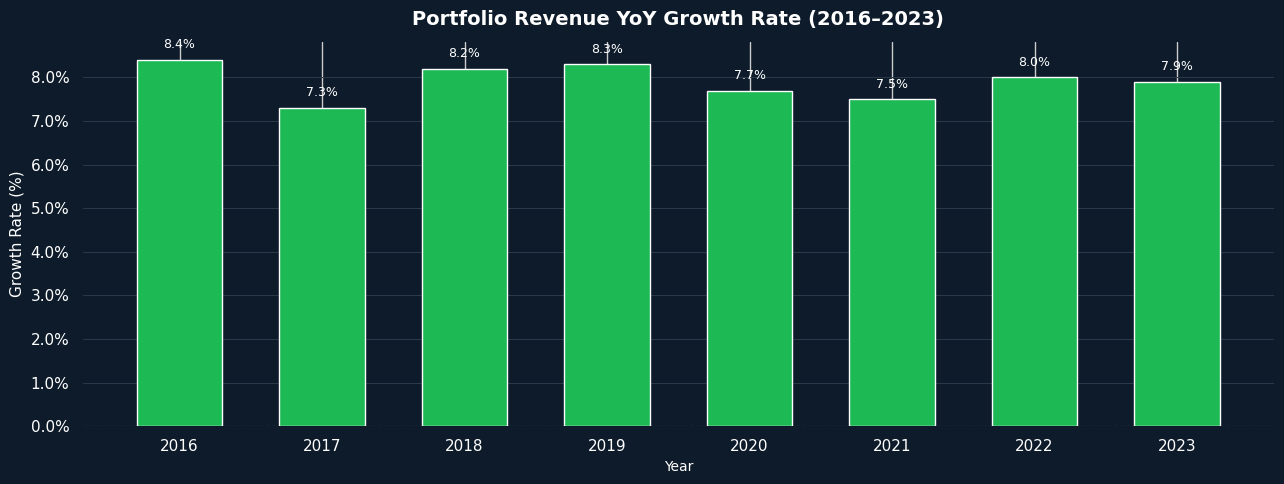

Chart 8 saved.


In [ ]:
growth_data = annual.dropna(subset=['Revenue_Growth'])

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

bar_colors = [ACCENT1 if v >= 0 else ACCENT4 for v in growth_data['Revenue_Growth']]
bars = ax.bar(growth_data['Year'], growth_data['Revenue_Growth'],
              color=bar_colors, width=0.6, zorder=3)
ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            h + (0.2 if h >= 0 else -0.8),
            f'{h:.1f}%', ha='center', va='bottom', color='white', fontsize=9)

ax.set_title('Portfolio Revenue YoY Growth Rate (2016–2023)', color='white', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Growth Rate (%)', color='white', fontsize=11)
ax.set_xlabel('Year', color='white', fontsize=10)
ax.tick_params(colors='white')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis='y', color='#2a3a4a', linewidth=0.7, zorder=0)
ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.savefig('/home/chart8_growth.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Chart 8 saved.')

## Cell 13 — Chart 9: Quarterly Revenue Heatmap per Company

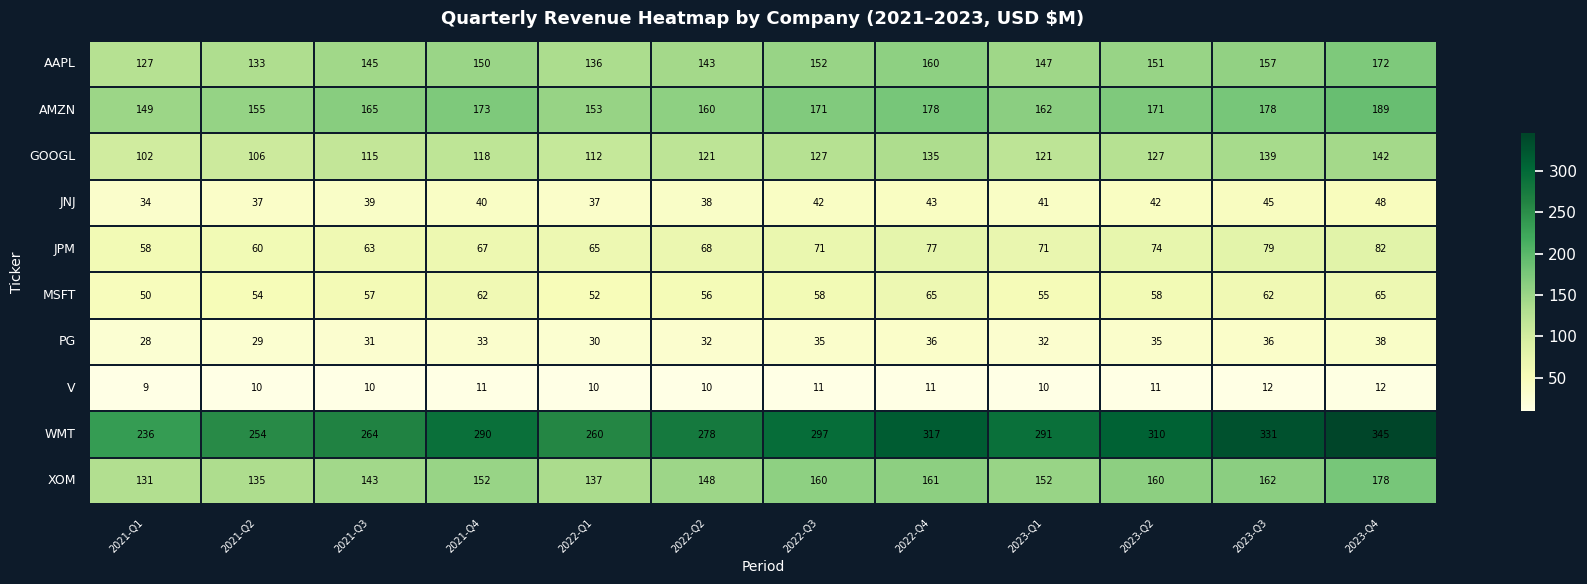

Chart 9 saved.


In [ ]:
# Pivot: rows = companies, columns = year-quarter periods
pivot_rev = (
    df[df['Year'].isin([2021, 2022, 2023])]
    .pivot_table(values='Revenue_USD_M', index='Ticker', columns='Period', aggfunc='sum')
)

fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

sns.heatmap(pivot_rev, cmap='YlGn', ax=ax, linewidths=0.3,
            linecolor='#0D1B2A', annot=True, fmt='.0f',
            annot_kws={'size': 7, 'color': 'black'},
            cbar_kws={'shrink': 0.6})

ax.set_title('Quarterly Revenue Heatmap by Company (2021–2023, USD $M)', color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Ticker', color='white', fontsize=10)
ax.set_xlabel('Period', color='white', fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', color='white', fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0, color='white', fontsize=9)
ax.figure.axes[-1].tick_params(colors='white')

plt.tight_layout()
plt.savefig('/home/chart9_heatmap.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Chart 9 saved.')

## Cell 14 — Chart 10: Expense Structure (Pie/Donut for 2023)

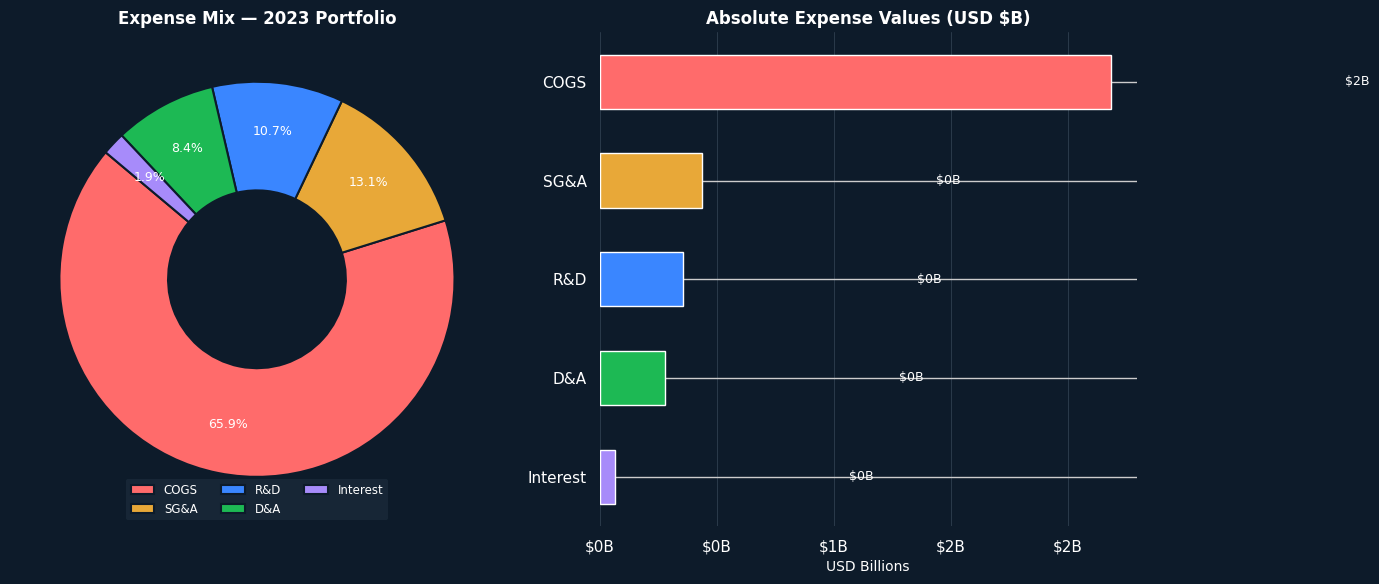

Chart 10 saved.


In [ ]:
exp_2023 = df[df['Year'] == 2023].agg({
    'COGS_USD_M': 'sum',
    'SGA_Expense_USD_M': 'sum',
    'RD_Expense_USD_M': 'sum',
    'DA_USD_M': 'sum',
    'Interest_Expense_USD_M': 'sum',
})

labels_pie = ['COGS', 'SG&A', 'R&D', 'D&A', 'Interest']
colors_pie = [ACCENT4, ACCENT2, ACCENT3, ACCENT1, '#a78bfa']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(DARK_BG)

wedges, texts, autotexts = ax1.pie(
    exp_2023.values, labels=None, colors=colors_pie,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='#0D1B2A', linewidth=1.5)
)
for t in autotexts:
    t.set_color('white'); t.set_fontsize(9)
ax1.set_facecolor(DARK_BG)
ax1.set_title('Expense Mix — 2023 Portfolio', color='white', fontsize=12, fontweight='bold')
ax1.legend(labels_pie, loc='lower center', ncol=3, facecolor='#1a2a3a',
           edgecolor='none', labelcolor='white', fontsize=8.5)

# Bar for absolute values
ax2.set_facecolor(DARK_BG)
bars = ax2.barh(labels_pie[::-1], exp_2023.values[::-1] / 1000,
                color=colors_pie[::-1], zorder=3, height=0.55)
for bar in bars:
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'${bar.get_width():.0f}B', va='center', color='white', fontsize=9)
ax2.set_title('Absolute Expense Values (USD $B)', color='white', fontsize=12, fontweight='bold')
ax2.set_xlabel('USD Billions', color='white', fontsize=10)
ax2.tick_params(colors='white')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax2.grid(axis='x', color='#2a3a4a', linewidth=0.7, zorder=0)
ax2.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.savefig('/home/chart10_expense.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Chart 10 saved.')

## Cell 15 — Build Excel Dashboard

In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage
import os

wb = Workbook()

# ─── Color palette (openpyxl hex, no '#') ───
C_DARK    = '0D1B2A'
C_NAVY    = '0F2A44'
C_GREEN   = '1DB954'
C_AMBER   = 'E8A838'
C_BLUE    = '3A86FF'
C_RED     = 'FF6B6B'
C_WHITE   = 'FFFFFF'
C_LTGREY  = 'F0F4F8'
C_MIDGREY = 'CBD5E1'

def hdr_font(size=11, bold=True, color=C_WHITE):
    return Font(name='Arial', size=size, bold=bold, color=color)

def fill(hex_color):
    return PatternFill('solid', start_color=hex_color, end_color=hex_color)

def border(style='thin', color='CBD5E1'):
    s = Side(border_style=style, color=color)
    return Border(left=s, right=s, top=s, bottom=s)

def center():
    return Alignment(horizontal='center', vertical='center', wrap_text=True)

print('Excel workbook initialized.')

#SHEET 1:
cover = wb.active
cover.title = '📋 Cover'
cover.sheet_view.showGridLines = False

for col in range(1, 15):
    cover.column_dimensions[get_column_letter(col)].width = 12
for row in range(1, 50):
    cover.row_dimensions[row].height = 18

# Big title block
cover.merge_cells('B3:M6')
t = cover['B3']
t.value = '💼  FINANCIAL KPI DASHBOARD'
t.font = Font(name='Arial', size=28, bold=True, color=C_GREEN)
t.fill = fill(C_DARK)
t.alignment = center()

cover.merge_cells('B7:M8')
s = cover['B7']
s.value = 'CFO-Level Analysis  |  10 Major S&P 500 Companies  |  2015 – 2023'
s.font = Font(name='Arial', size=13, color=C_AMBER)
s.fill = fill(C_NAVY)
s.alignment = center()

# Info grid
info = [
    ('Dataset', 'Synthetic — modeled on public financial statements (Kaggle)'),
    ('Companies', 'AAPL · MSFT · AMZN · GOOGL · JNJ · JPM · XOM · PG · V · WMT'),
    ('Period', 'Q1 2015 – Q4 2023 (Quarterly, 360 records)'),
    ('KPIs Tracked', 'Revenue · COGS · Gross Profit · EBITDA · EBIT · Net Income · FCF · Margins'),
    ('Sheets', '10 Analysis Tabs + Raw Data'),
]
for i, (k, v) in enumerate(info):
    r = 11 + i * 2
    cover.merge_cells(f'B{r}:C{r}')
    cover[f'B{r}'].value = k
    cover[f'B{r}'].font = Font(name='Arial', size=10, bold=True, color=C_WHITE)
    cover[f'B{r}'].fill = fill(C_NAVY)
    cover[f'B{r}'].alignment = center()
    cover.merge_cells(f'D{r}:M{r}')
    cover[f'D{r}'].value = v
    cover[f'D{r}'].font = Font(name='Arial', size=10, color=C_DARK)
    cover[f'D{r}'].fill = fill(C_LTGREY)
    cover[f'D{r}'].alignment = Alignment(horizontal='left', vertical='center', indent=1)

print('Cover sheet done.')

# Helper: embed a PNG chart into a sheet
def embed_chart(ws, img_path, anchor='B3', w_cm=24, h_cm=14):
    if os.path.exists(img_path):
        img = XLImage(img_path)
        img.width  = w_cm * 37.8   # cm → px approx
        img.height = h_cm * 37.8
        ws.add_image(img, anchor)

def sheet_header(ws, title, subtitle=''):
    ws.sheet_view.showGridLines = False
    ws.merge_cells('A1:P1')
    ws['A1'].value = title
    ws['A1'].font  = Font(name='Arial', size=16, bold=True, color=C_WHITE)
    ws['A1'].fill  = fill(C_DARK)
    ws['A1'].alignment = center()
    ws.row_dimensions[1].height = 32
    if subtitle:
        ws.merge_cells('A2:P2')
        ws['A2'].value = subtitle
        ws['A2'].font  = Font(name='Arial', size=10, color=C_AMBER)
        ws['A2'].fill  = fill(C_NAVY)
        ws['A2'].alignment = center()
        ws.row_dimensions[2].height = 18

# SHEET 2: Executive KPI Summary
ws_kpi = wb.create_sheet('📊 KPI Summary')
sheet_header(ws_kpi, '📊 Executive KPI Summary — Portfolio (2015–2023)',
             'Aggregated across all 10 companies · USD Millions')
ws_kpi.sheet_view.showGridLines = False

kpi_cols_headers = [
    'Year', 'Revenue', 'COGS', 'Gross Profit', 'EBITDA', 'EBIT',
    'Net Income', 'CFO', 'Capex', 'FCF',
    'Gross Margin', 'EBITDA Margin', 'Net Margin', 'FCF Margin', 'Rev Growth'
]
col_widths = [8, 12, 12, 13, 12, 12, 12, 12, 10, 12, 13, 14, 12, 12, 12]

for ci, (h, w) in enumerate(zip(kpi_cols_headers, col_widths), 1):
    cell = ws_kpi.cell(row=4, column=ci, value=h)
    cell.font = Font(name='Arial', size=10, bold=True, color=C_WHITE)
    cell.fill = fill(C_NAVY)
    cell.alignment = center()
    cell.border = border()
    ws_kpi.column_dimensions[get_column_letter(ci)].width = w

pct_cols  = {11, 12, 13, 14, 15}
money_cols= {2, 3, 4, 5, 6, 7, 8, 9, 10}

for ri, row in enumerate(annual.itertuples(), 5):
    vals = [
        row.Year, row.Revenue, row.COGS, row.Gross_Profit,
        row.EBITDA, row.EBIT, row.Net_Income, row.CFO,
        row.Capex, row.FCF,
        row.Gross_Margin / 100, row.EBITDA_Margin / 100,
        row.Net_Margin / 100, row.FCF_Margin / 100,
        (row.Revenue_Growth / 100 if pd.notna(row.Revenue_Growth) else None)
    ]
    bg = C_WHITE if ri % 2 == 1 else C_LTGREY
    for ci, v in enumerate(vals, 1):
        c = ws_kpi.cell(row=ri, column=ci, value=v)
        c.font = Font(name='Arial', size=9)
        c.fill = fill(bg)
        c.alignment = center()
        c.border = border()
        if ci in pct_cols and v is not None:
            c.number_format = '0.0%;(0.0%);-'
            c.font = Font(name='Arial', size=9,
                          color=('1DB954' if v >= 0 else 'FF6B6B'))
        elif ci in money_cols:
            c.number_format = '#,##0;(#,##0);-'

print('KPI Summary sheet done.')

# SHEET 3: Revenue & EBITDA Chart
ws_c1 = wb.create_sheet(' Revenue & EBITDA')
sheet_header(ws_c1, 'Revenue & EBITDA Trend (2015–2023)',
             'Combined bar + line chart | EBITDA Margin overlay')
for c in range(1, 30): ws_c1.column_dimensions[get_column_letter(c)].width = 3.5
embed_chart(ws_c1, '/home/chart1_revenue_ebitda.png', 'B4', 28, 16)

#SHEET 4: Margin Analysis
ws_c2 = wb.create_sheet(' Margin Trends')
sheet_header(ws_c2, ' Margin Trends — Gross / EBITDA / Net / FCF',
             'All four key margins tracked 2015–2023')
for c in range(1, 30): ws_c2.column_dimensions[get_column_letter(c)].width = 3.5
embed_chart(ws_c2, '/home/chart2_margins.png', 'B4', 28, 16)

#SHEET 5: Cash Flow Waterfall
ws_c3 = wb.create_sheet(' Cash Flow Waterfall')
sheet_header(ws_c3, ' Cash Flow Waterfall — 2023 Snapshot',
             'Revenue → COGS → Gross Profit → EBITDA → Net Income → FCF')
for c in range(1, 30): ws_c3.column_dimensions[get_column_letter(c)].width = 3.5
embed_chart(ws_c3, '/home/chart3_waterfall.png', 'B4', 28, 17)

#SHEET 6: Bubble Benchmarking
ws_c4 = wb.create_sheet(' Company Benchmark')
sheet_header(ws_c4, 'Company Benchmarking — Revenue vs EBITDA Margin',
             'Bubble size = FCF | 2023 data')
for c in range(1, 30): ws_c4.column_dimensions[get_column_letter(c)].width = 3.5
embed_chart(ws_c4, '/home/chart4_bubble.png', 'B4', 27, 17)

#SHEET 7: Sector Revenue
ws_c5 = wb.create_sheet(' Sector Revenue')
sheet_header(ws_c5, ' Portfolio Revenue by Sector (2015–2023)',
             'Stacked bar chart across all years')
for c in range(1, 30): ws_c5.column_dimensions[get_column_letter(c)].width = 3.5
embed_chart(ws_c5, '/home/chart5_sector_stacked.png', 'B4', 28, 16)

#SHEET 8: FCF vs Capex
ws_c6 = wb.create_sheet(' FCF vs CapEx')
sheet_header(ws_c6, ' Free Cash Flow vs CapEx by Company (2023)',
             'Horizontal grouped bar chart')
for c in range(1, 30): ws_c6.column_dimensions[get_column_letter(c)].width = 3.5
embed_chart(ws_c6, '/home/chart6_fcf_capex.png', 'B4', 26, 17)

#SHEET 9: Correlation Heatmap ─
ws_c7 = wb.create_sheet(' KPI Correlations')
sheet_header(ws_c7, ' KPI Correlation Heatmap',
             'Pearson correlation across all KPI metrics')
for c in range(1, 30): ws_c7.column_dimensions[get_column_letter(c)].width = 3.5
embed_chart(ws_c7, '/home/chart7_corr.png', 'B4', 24, 18)

#SHEET 10: Revenue Growth
ws_c8 = wb.create_sheet(' Revenue Growth')
sheet_header(ws_c8, 'Portfolio Revenue YoY Growth Rate (2016–2023)',
             'Green = positive growth | Red = contraction')
for c in range(1, 30): ws_c8.column_dimensions[get_column_letter(c)].width = 3.5
embed_chart(ws_c8, '/home/chart8_growth.png', 'B4', 27, 14)

#  SHEET 11: Quarterly Heatmap
ws_c9 = wb.create_sheet('Quarterly Heatmap')
sheet_header(ws_c9, ' Quarterly Revenue Heatmap by Company (2021–2023)',
             'Color intensity = revenue magnitude (USD $M)')
for c in range(1, 45): ws_c9.column_dimensions[get_column_letter(c)].width = 3.2
embed_chart(ws_c9, '/home/chart9_heatmap.png', 'B4', 40, 15)

#SHEET 12: Expense Structure
ws_c10 = wb.create_sheet(' Expense Structure')
sheet_header(ws_c10, ' Expense Structure — 2023 Portfolio',
             'Donut + horizontal bar — COGS · SG&A · R&D · D&A · Interest')
for c in range(1, 30): ws_c10.column_dimensions[get_column_letter(c)].width = 3.5
embed_chart(ws_c10, '/home/chart10_expense.png', 'B4', 28, 16)

#SHEET 13: Raw Data
ws_raw = wb.create_sheet(' Raw Data')
sheet_header(ws_raw, ' Raw Financial Data — All Companies / All Quarters',
             '360 records | 28 columns | 2015 Q1 – 2023 Q4')

for ci, col in enumerate(df.columns, 1):
    c = ws_raw.cell(row=4, column=ci, value=col)
    c.font = Font(name='Arial', size=9, bold=True, color=C_WHITE)
    c.fill = fill(C_NAVY)
    c.alignment = center()
    c.border = border()
    ws_raw.column_dimensions[get_column_letter(ci)].width = max(len(col) + 2, 10)

for ri, row in enumerate(df.itertuples(index=False), 5):
    bg = C_WHITE if ri % 2 == 0 else C_LTGREY
    for ci, v in enumerate(row, 1):
        c = ws_raw.cell(row=ri, column=ci, value=v)
        c.font = Font(name='Arial', size=8)
        c.fill = fill(bg)
        c.alignment = Alignment(horizontal='center', vertical='center')
        c.border = border()

ws_raw.freeze_panes = 'A5'

# Save
out_path = '/home/Financial_KPI_Dashboard.xlsx'
wb.save(out_path)
print(f'\nExcel dashboard saved → {out_path}')
print(f'   Sheets: {len(wb.sheetnames)}')

Excel workbook initialized.
Cover sheet done.
KPI Summary sheet done.

Excel dashboard saved → /home/Financial_KPI_Dashboard.xlsx
   Sheets: 13


## Cell 16 — Final Summary

In [ ]:
print('=' * 65)
print('   FINANCIAL KPI DASHBOARD — PROJECT COMPLETE')
print('=' * 65)

latest_yr = annual[annual['Year'] == 2023].iloc[0]
prev_yr   = annual[annual['Year'] == 2022].iloc[0]

def delta(curr, prev):
    return f"{'▲' if curr > prev else '▼'} {abs((curr - prev)/prev * 100):.1f}%"

print(f"\n 2023 Portfolio Snapshot (All 10 Companies Combined)")
print(f"   Revenue     : ${latest_yr['Revenue']/1000:.1f}B  {delta(latest_yr['Revenue'], prev_yr['Revenue'])}")
print(f"   EBITDA      : ${latest_yr['EBITDA']/1000:.1f}B  {delta(latest_yr['EBITDA'], prev_yr['EBITDA'])}")
print(f"   Net Income  : ${latest_yr['Net_Income']/1000:.1f}B  {delta(latest_yr['Net_Income'], prev_yr['Net_Income'])}")
print(f"   FCF         : ${latest_yr['FCF']/1000:.1f}B  {delta(latest_yr['FCF'], prev_yr['FCF'])}")
print(f"   EBITDA Margin: {latest_yr['EBITDA_Margin']:.1f}%")
print(f"   Net Margin   : {latest_yr['Net_Margin']:.1f}%")

print(f"\nOutput Files:")
print(f"   financial_kpi_dataset.csv         ← Dataset (360 rows)")
print(f"   Financial_KPI_Dashboard.xlsx      ← Excel Dashboard (13 sheets + 10 charts)")
print(f"   Financial_KPI_Dashboard.ipynb     ← This notebook")
print('=' * 65)

   FINANCIAL KPI DASHBOARD — PROJECT COMPLETE

 2023 Portfolio Snapshot (All 10 Companies Combined)
   Revenue     : $4.7B  ▲ 7.9%
   EBITDA      : $1.7B  ▲ 23.5%
   Net Income  : $1.1B  ▲ 31.5%
   FCF         : $1.0B  ▲ 23.0%
   EBITDA Margin: 36.7%
   Net Margin   : 23.1%

Output Files:
   financial_kpi_dataset.csv         ← Dataset (360 rows)
   Financial_KPI_Dashboard.xlsx      ← Excel Dashboard (13 sheets + 10 charts)
   Financial_KPI_Dashboard.ipynb     ← This notebook
